# Day 4: Big Data + PySpark + Modern Data Architecture



#  Big Data
Big Data means very large and complex data that cannot be handled using normal tools like Excel,Pandas or sinngle database

It is used to store, process, and analyze huge data to get useful information.

---

##  5 V’s of Big Data
- **Volume** → Size of data
- **Velocity** → Data comes very fast  
- **Variety** → Different types of data (text, images, videos)  
- **Veracity** → Accuracy of data  
- **Value** → Useful information from data  

---

##  Pandas Limitation
- Works only on single computer
- Works only in computer memory (RAM)  
- Cannot handle very large data (GB/TB level)  
- Slower for big data processing  
  

---

##  Apache Spark
Apache Spark is a big data tool used to process large datasets very fast.

- Uses multiple computers (distributed system)  
- Distributed storage
- Works with large data  
- Faster than Pandas  
- Used for batch and real-time processing  

---

##  PySpark
PySpark is the Python version of Apache Spark.

It allows us to use Spark using Python code instead of Scala or Java.

---

##  Spark vs PySpark

- **Apache Spark** → Main big data engine (written in Scala)  
- **PySpark** → Python way to use Spark  

### Simple Difference:
- Spark = Engine  
- PySpark = Python control for that engine  



In [6]:
!pip install pyspark --quiet                              # install pyspark
print("Python Installation Complete!")

Python Installation Complete!


In [7]:
# import pyspark module

from pyspark.sql import SparkSession             # entry-point , create spark application
from pyspark.sql import functions as functions   # import spark SQL functions module
from pyspark.sql.functions import year,month, to_date, col,round as spark_round
from pyspark.sql import functions as F           # another alias for Spark functions

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# start building SparkSession
# app name
# Adaptive Query Execution
# create new one, if already exist reuse

spark = SparkSession.builder.appName('Day_04_BigData_PySpark_Architecture').config('spark.sql.adaptive.enabled','true').getOrCreate()
print(f'Spark version  : {spark.version}')
print(f'SparkSession   : ACTIVE')
print(f'Application    : {spark.sparkContext.appName}')

Spark version  : 4.0.2
SparkSession   : ACTIVE
Application    : Day_04_BigData_PySpark_Architecture


 # Transformations vs Actions

**Transformations:** operations that create a new dataframe from an existing one.

**Examples:**

`select(`) → choose columns

`filter()` → select specific rows

`withColumn(`) → add/modify column

`groupBy(`) → group data

`orderBy(`) → sort data

`drop()` → remove columns

`df.dropDuplicates()` → Remove duplicate rows


**Actions:** operations that execute the transformations and give result.

Examples :

`show()` → display data

`count()` → number of rows

`collect()` → get all data to driver

`first()` → first row

`df.toPandas()` → convert to pandas df

`df.write.csv()` → save results to csv file

`df.write.parquet()` → save as parquet format

```
large_sales_data.csv (5000 rows)
       |
  [BRONZE]  Load raw CSV → save as Parquet
       |
  [SILVER]  Clean + transform with PySpark
       |
  [GOLD]    Aggregate → business insights
       |
  [VISUALIZE] Convert to Pandas → charts
```

## BRONZE LAYER — Extract Raw Data

In Medallion Architecture, the **Bronze layer** holds raw data exactly as received — no modifications.

In [8]:


# Load data, first row is header, store is as df
df_bronze = spark.read\
    .option('header','true')\
    .csv('large_sales_data.csv')

print('=== BRONZE LAYER --Raw Data ===')

# count all records in df
print(f'Rows : {df_bronze.count()}')

# count number of columns
print(f'Columns : {len(df_bronze.columns)}')

print()

# schema (column names, datatypes, nullable)
df_bronze.printSchema()

=== BRONZE LAYER --Raw Data ===
Rows : 5000
Columns : 13

root
 |-- order_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- unit_price: string (nullable = true)
 |-- revenue: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [9]:
print('First 5 rows:')
df_bronze.show(5,truncate=False)          # show -> dsiplay data from the dataframe
                                          # truncate = False, Full value is displayed (by default spark shorterns long text)
print('\n Basic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()       # select -> new df, describe-> basic statistics, show ->display

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [10]:
df_bronze.write.mode('overwrite').parquet('sales_bronze.parquet')
# write -> save df to storage
# .mode('overwrite) -> Specifies what Spark should do if the destination already exists.
# save in parquet format.
print('Bronze Parquet saved: sales_bronze.parquet')

Bronze Parquet saved: sales_bronze.parquet


SILVER LAYER - Clean and Transform

In [14]:
# remove rows that are exactly identical
#dropna -> delete null values rows
df_silver=df_bronze\
.dropDuplicates()\
.dropna(subset=['order_id','product','revenue'])

# update df-> convert order_date (str to date)
df_silver = df_silver.withColumn('order_date',to_date(col('order_date'),'yyyy-MM-dd'))

In [15]:
# extracts the year
# extracts the month
df_silver = df_silver \
.withColumn('order_year',year(col('order_date'))) \
.withColumn('order_month',month(col('order_date')))

In [16]:
#create new col, when -> works like if
df_silver = df_silver.withColumn(
    "revenue_category",
    F.when(col("revenue") > 40000, "High")
     .when(col("revenue") > 10000, "Medium")
     .otherwise("Low")
)

print(f'Silver layer rows: {df_silver.count()}')
print('New columns added: order_year, order_month, revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(4)

Silver layer rows: 5000
New columns added: order_year, order_month, revenue_category
+--------+-------+----------+-----------+----------------+
| product|revenue|order_year|order_month|revenue_category|
+--------+-------+----------+-----------+----------------+
| Printer|  12000|      2023|         11|          Medium|
|   Mouse|   8000|      2023|          7|             Low|
|  Webcam|  17500|      2023|         10|          Medium|
|Keyboard|  14400|      2023|          2|          Medium|
+--------+-------+----------+-----------+----------------+
only showing top 4 rows


In [17]:
import os
# function calculates the size of a file or folder in KB (Kilobytes).

def get_dir_size(path):
    if os.path.isfile(path):                     # if path points to a file
        return os.path.getsize(path) / 1024      # fetsize() -> bytes

    total = 0

    for dirpath, dirnames, filenames in os.walk(path):  # find all files
        for file in filenames:
            file_path = os.path.join(dirpath, file)
            total += os.path.getsize(file_path)

    return total / 1024

In [18]:
df_silver.write \
.mode('overwrite') \
.parquet('sales_silver.parquet')
print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size:{get_dir_size("sales_silver.parquet"):.1f}KB')

Silver Parquet saved: sales_silver.parquet
Silver size:63.8KB


In [19]:
df_verify = spark.read.parquet('sales_silver.parquet')
print(f'Read-back rows:{df_verify.count()}(should match silver count)')
df_verify.printSchema()

Read-back rows:5000(should match silver count)
root
 |-- order_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- unit_price: string (nullable = true)
 |-- revenue: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



Six queries using SELECT, FILTER, GROUPBY, ORDERBY.

In [20]:
# Query1: Top 5 products by total revenue

top_products = df_silver\
.groupby('product')\
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('num_orders'),
    F.avg('revenue').alias('avg_order_revenue')
) \
.orderBy('total_revenue',ascending=False)\
.limit(5)

print('=== TOP 5 PRODUCTS BY REVENUE ===')
top_products.show(truncate=False)

=== TOP 5 PRODUCTS BY REVENUE ===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |1.827E8      |502       |363944.22310756973|
|Tablet |1.35104E8    |532       |253954.8872180451 |
|Monitor|8.2126E7     |481       |170740.12474012474|
|Printer|4.4544E7     |488       |91278.68852459016 |
|Speaker|1.6317E7     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [21]:
# Query2: Revenue by region
region_revenue = df_silver\
.groupBy('region')\
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('total_order'),
    F.countDistinct('customer_name').alias('unique_customers')
) \
.orderBy('total_revenue',ascending= False)
print('=== Revenue by Region ===')
region_revenue.show(truncate=False)

=== Revenue by Region ===
+------+-------------+-----------+----------------+
|region|total_revenue|total_order|unique_customers|
+------+-------------+-----------+----------------+
|West  |1.982756E8   |2021       |15              |
|South |1.471459E8   |1483       |15              |
|North |9.98784E7    |995        |15              |
|East  |5.05477E7    |501        |15              |
+------+-------------+-----------+----------------+



In [22]:
# Query3: Monthly revenue trend
monthly_trend = df_silver \
.groupBy('order_month') \
.agg(F.sum('revenue').alias('monthly_revenue'),
     F.count('order_id').alias('monthly_orders')) \
     .orderBy('order_month')

print('=== Monthly Revenue Trend ===')
monthly_trend.show(12)


=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|      4.10682E7|           423|
|          2|      3.44854E7|           375|
|          3|      4.00312E7|           451|
|          4|      3.88571E7|           390|
|          5|      3.99845E7|           423|
|          6|      4.07074E7|           390|
|          7|      4.26407E7|           405|
|          8|      4.37185E7|           418|
|          9|      3.76402E7|           398|
|         10|       4.7839E7|           479|
|         11|      4.45771E7|           419|
|         12|      4.42983E7|           429|
+-----------+---------------+--------------+



In [23]:
# Query4: Filter — High-value Electronics orders

high_value_electronics =df_silver \
.filter(
    (col('category')=='Electronics') &
    (col('revenue')>50000)
)\
.select('customer_name','product','revenue','city','order_status')\
.orderBy('revenue',ascending=False)
print('=== High-Value Electronics Orders (revenue > 50,000)===')
high_value_electronics.show(10,truncate=False)
print(f'Total such orders: {high_value_electronics.count()}')

=== High-Value Electronics Orders (revenue > 50,000)===
+-------------+-------+-------+---------+------------+
|customer_name|product|revenue|city     |order_status|
+-------------+-------+-------+---------+------------+
|Sneha Reddy  |Tablet |96000  |Chennai  |Cancelled   |
|Meera Joshi  |Printer|96000  |Hyderabad|Shipped     |
|Tanvi Mehta  |Tablet |96000  |Surat    |Processing  |
|Ramesh Kumar |Tablet |96000  |Surat    |Processing  |
|Rahul Mishra |Printer|96000  |Bangalore|Delivered   |
|Ramesh Kumar |Printer|96000  |Ahmedabad|Processing  |
|Arjun Nair   |Tablet |96000  |Hyderabad|Processing  |
|Kiran Kumar  |Tablet |96000  |Pune     |Shipped     |
|Pooja Gupta  |Tablet |96000  |Chennai  |Processing  |
|Divya Singh  |Tablet |96000  |Surat    |Cancelled   |
+-------------+-------+-------+---------+------------+
only showing top 10 rows
Total such orders: 1844


In [24]:
# Query5: Sales rep performance

sales_rep_perf = df_silver \
    .groupBy('sales_rep') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('orders_closed'),
        spark_round(F.avg('revenue'), 2).alias('avg_deal_size')
    ) \
    .orderBy('total_revenue', ascending=False)
print('=== Sales Rep Performance ===')
sales_rep_perf.show(truncate=False)

=== Sales Rep Performance ===
+------------+-------------+-------------+-------------+
|sales_rep   |total_revenue|orders_closed|avg_deal_size|
+------------+-------------+-------------+-------------+
|Suresh Iyer |6.88153E7    |642          |107188.94    |
|Sunita Rao  |6.64061E7    |652          |101849.85    |
|Ravi Kumar  |6.52345E7    |645          |101138.76    |
|Deepak Joshi|6.30531E7    |655          |96264.27     |
|Anil Sharma |6.12566E7    |622          |98483.28     |
|Priya Nair  |5.95497E7    |609          |97782.76     |
|Meera Patel |5.85295E7    |594          |98534.51     |
|Kavya Reddy |5.30028E7    |581          |91226.85     |
+------------+-------------+-------------+-------------+



In [25]:
# Query6: Payment method breakdown
payment_breakdown = df_silver \
    .groupBy('payment_method') \
    .agg(
        F.count('order_id').alias('num_transactions'),
        F.sum('revenue').alias('total_revenue')
    ) \
    .withColumn(
        'pct_of_orders',
        spark_round(
            F.col('num_transactions') / F.lit(df_silver.count()) * 100, 1
        )
    ) \
    .orderBy('num_transactions', ascending=False)
print('=== Payment Method Breakdown ===')
payment_breakdown.show(truncate=False)

=== Payment Method Breakdown ===
+----------------+----------------+-------------+-------------+
|payment_method  |num_transactions|total_revenue|pct_of_orders|
+----------------+----------------+-------------+-------------+
|Cash on Delivery|1286            |1.302205E8   |25.7         |
|UPI             |1277            |1.281915E8   |25.5         |
|Credit Card     |1224            |1.180817E8   |24.5         |
|Net Banking     |1213            |1.193539E8   |24.3         |
+----------------+----------------+-------------+-------------+



In [26]:
# Table 1
gold_region = region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('Gold 1 saved: gold_region_revenue.parquet')
# Table 2
gold_products = df_silver \
    .groupBy('product','category') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.sum('order_id').alias('units_sold'),
        spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
        F.max('revenue').alias('largest_order')
    ) \
    .orderBy('total_revenue',ascending=False)
gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')
print('Gold 2 saved: gold_product_summary.parquet')

gold_monthly = monthly_trend
gold_monthly.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('Gold 3 saved: gold_monthly_trend.parquet')
print('\nMedallion Pipeline Complete:')
print('  BRONZE → sales_bronze.parquet(raw data)')
print('  SILVER → sales_silver.parquet(cleaned + enriched)')
print('  GOLD   → gold_region_revenue.parquet')
print('         → gold_product_summary.parquet')
print('         → gold_monthly_trend.parquet')

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_product_summary.parquet
Gold 3 saved: gold_monthly_trend.parquet

Medallion Pipeline Complete:
  BRONZE → sales_bronze.parquet(raw data)
  SILVER → sales_silver.parquet(cleaned + enriched)
  GOLD   → gold_region_revenue.parquet
         → gold_product_summary.parquet
         → gold_monthly_trend.parquet


# Practice Questions

## Q1: Explain the 5 Vs of Big Data using Flipkart as an example

- **Volume** – Millions of product listings and orders.
- **Velocity** – Real-time order and payment processing.
- **Variety** – Data from reviews, images, videos, and transactions.
- **Veracity** – Ensuring customer and product data is accurate.
- **Value** – Using data for recommendations and business insights.

---
## Q2. Difference between Transformation and Action in PySpark

| Transformation | Action |
|---------------|---------|
| Creates a new DataFrame/RDD | Executes the computation |
| Lazy evaluation | Triggers execution |

**Example Transformation:** `df.filter(col("revenue") > 1000)`

**Example Action:** `df.count()`

---

## Q3: Write PySpark code to find the top 5 cities by total revenue.

In [27]:
top_cities = df_silver \
    .groupBy('city') \
    .agg(F.sum('revenue').alias('total_revenue'),
         F.count('order_id').alias('orders')) \
    .orderBy('total_revenue', ascending=False) \
    .limit(5)
print('Answer Q3: Top 5 Cities by Revenue:')
top_cities.show(truncate=False)

Answer Q3: Top 5 Cities by Revenue:
+-------+-------------+------+
|city   |total_revenue|orders|
+-------+-------------+------+
|Chennai|5.25767E7    |514   |
|Surat  |5.21575E7    |545   |
|Delhi  |5.19271E7    |490   |
|Pune   |5.18823E7    |500   |
|Kolkata|5.05477E7    |501   |
+-------+-------------+------+



# Q4: Why is Parquet preferred over CSV for Big Data? Give three reasons.
- Columnar storage for faster queries.
- Supports compression, reducing storage size.
- Better performance for Big Data analytics.



## Q5: What is Medallion Architecture? Describe each layer.

### Definition

Medallion Architecture is a data design pattern used in modern data engineering and data lakehouse systems to organize data into different quality levels.
### Layers of Medallion Architecture

### 1. Bronze Layer (Raw Data)

- Stores data in its original form as received from source systems.

**Example:**
- Raw CSV files from sales transactions.
- JSON logs collected from applications.

### 2. Silver Layer (Cleaned and Validated Data)

- Data is cleaned, standardized, and validated.
- Handles missing values, duplicates, and incorrect formats.
- Combines data from multiple sources if needed.

**Example:**
- Removing duplicate customer records.
- Converting date formats into a standard format.

### 3. Gold Layer (Business-Ready Data)

- Contains aggregated data
- Used by dashboards, business intelligence tools, and machine learning models.
- Provides high-quality datasets for decision-making.

**Example:**
- Monthly sales summary by region.
- Customer lifetime value reports.
```


## Q6: What is the difference between a Data Lake and a Data Warehouse?
| Data Lake                                      | Data Warehouse            |
| ---------------------------------------------- | ------------------------- |
| Stores raw data                                | Stores processed data     |
| Structured, semi-structured, unstructured data | Mostly structured data    |
| Used for data science and ML                   | Used for reporting and BI |



Gold layer = Aggregated Business Tables, optimized for dashboards and reporting.

# MINIPROJECT 4- Visualization Dashboard from Gold Layer

In [28]:
region_pd = spark.read.parquet('gold_region_revenue.parquet').toPandas()
product_pd = spark.read.parquet('gold_product_summary.parquet').toPandas()
monthly_pd = spark.read.parquet('gold_monthly_trend.parquet').toPandas()

print('Gold tables converted to Pandas:')
print(f' Region   :{region_pd.shape}')
print(f' Products :{product_pd.shape}')
print(f' Monthly  :{monthly_pd.shape}')

region_pd  = region_pd.sort_values('total_revenue', ascending=False)
product_pd = product_pd.sort_values('total_revenue', ascending=False)
monthly_pd = monthly_pd.sort_values('order_month')

Gold tables converted to Pandas:
 Region   :(4, 4)
 Products :(10, 6)
 Monthly  :(12, 3)


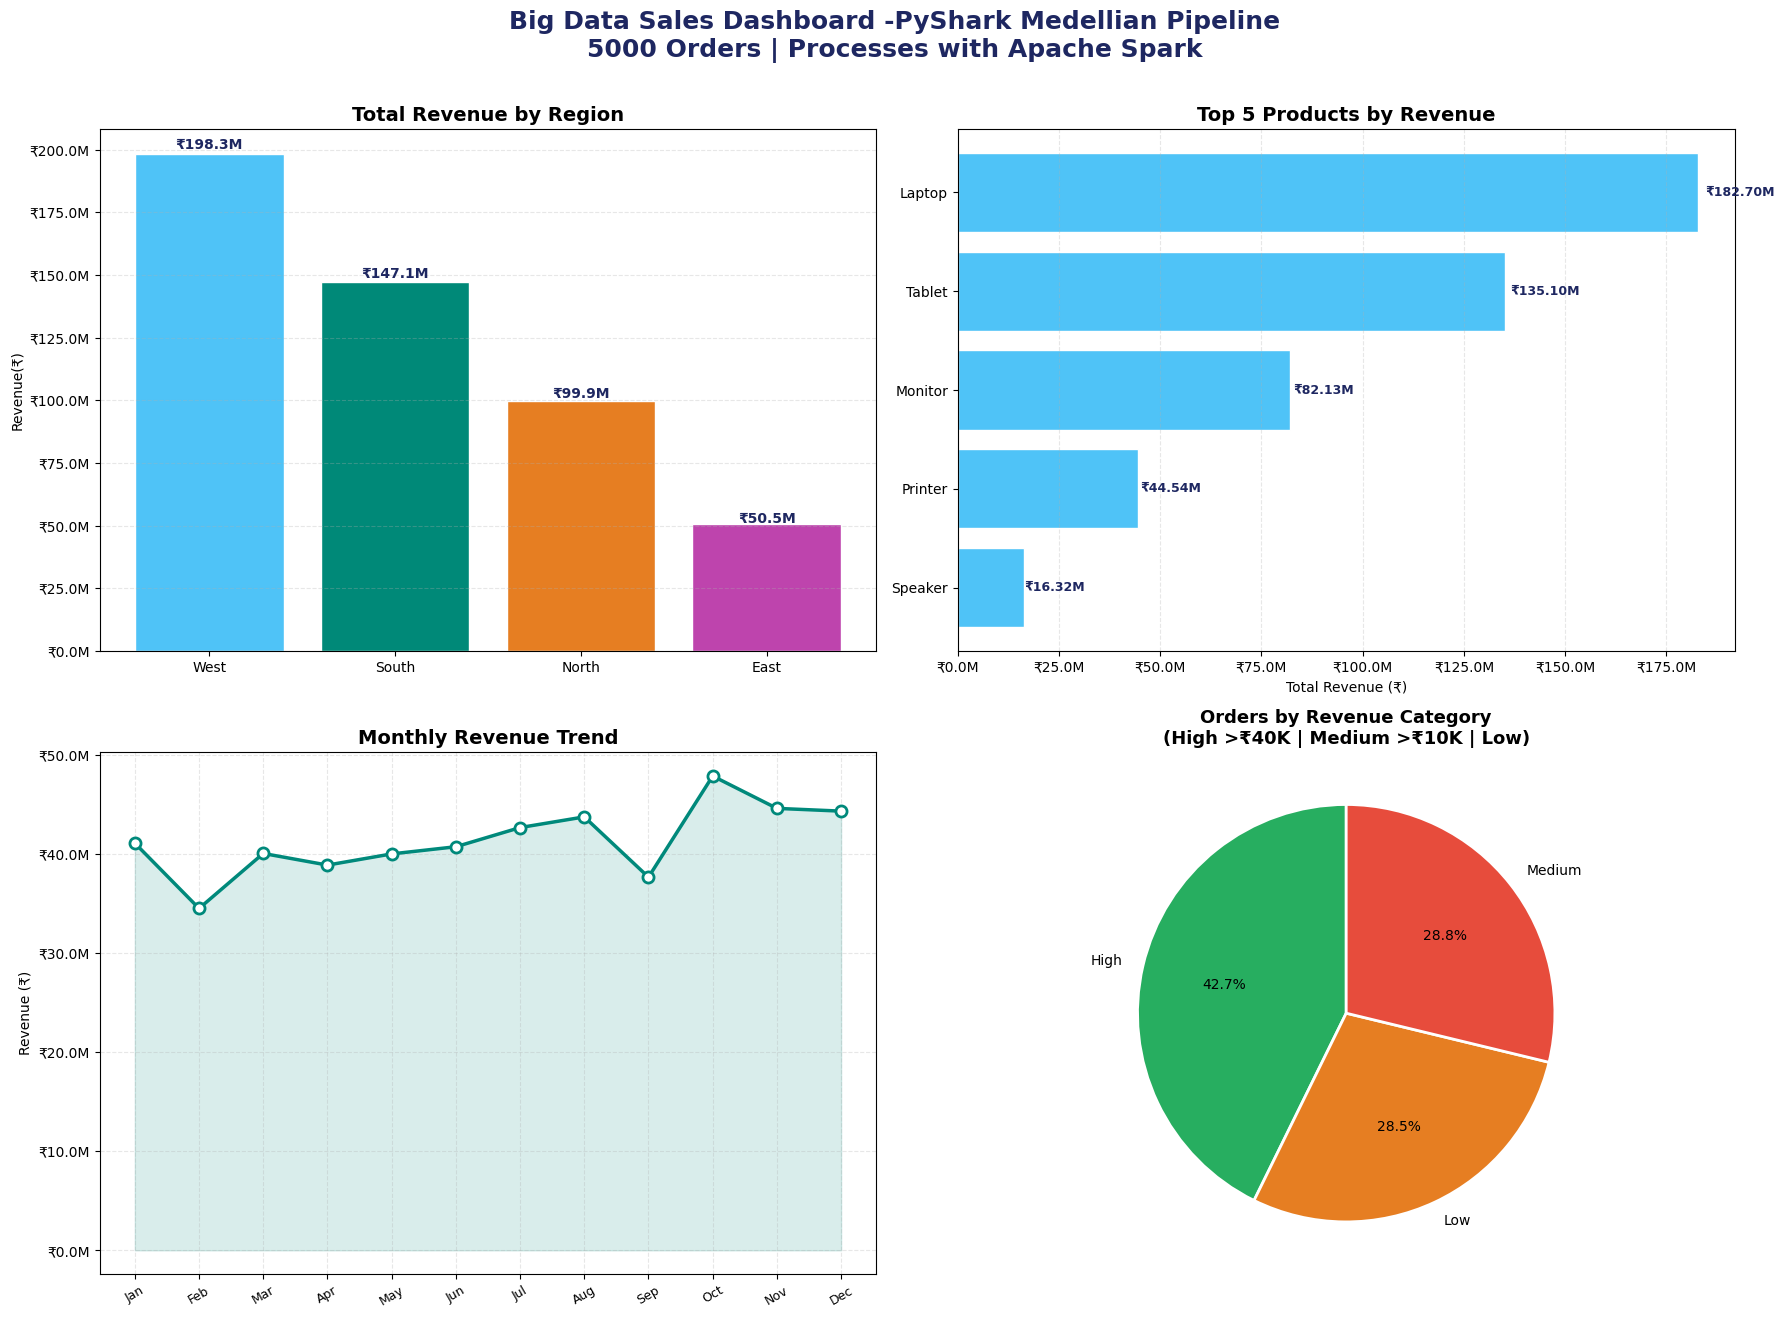

Dashboard saved: big_data_dashboard.png


In [29]:
fig, axes = plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
     'Big Data Sales Dashboard -PyShark Medellian Pipeline\n'
     '5000 Orders | Processes with Apache Spark',
     fontsize=18,fontweight='bold',color='#1E2761',y=1.01

)
colors=['#4FC3F7','#008978','#E67E22','#BE44AD','#E74C3C']
# Panel 1
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],
              color=colors[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
           ha='center',fontsize=10,fontweight='bold',color='#1E2761')

ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue(₹)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y',alpha=0.3,linestyle='--')

#Panel 2
ax2=axes[0][1]
top5_prod = product_pd.head(5).sort_values('total_revenue')
bars2=ax2.barh(top5_prod['product'],top5_prod['total_revenue'],
               color='#4FC3F7',edgecolor='white')
for bar in bars2:
  ax2.text(bar.get_width()*1.01,bar.get_y()+bar.get_height()/2,
           f'₹{bar.get_width()/1e6:.2f}M',
           va='center',fontsize=9,fontweight='bold',color='#1E2761')
ax2.set_title('Top 5 Products by Revenue',fontsize=14,fontweight='bold')
ax2.set_xlabel('Total Revenue (₹)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'₹{x/1e6:.1f}M'))
ax2.grid(axis='x',alpha=0.3,linestyle='--')

# Panel 3
ax3 = axes[1][0]
month_names=['Jan','Feb','Mar','Apr','May','Jun',
             'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels = [month_names[m-1] for m in monthly_pd['order_month']]

ax3.plot(monthly_labels, monthly_pd['monthly_revenue'],
         marker='o', linewidth=2.5, color='#00897B',
         markersize=8, markerfacecolor='white', markeredgewidth=2)
ax3.fill_between(range(len(monthly_labels)),
                 monthly_pd['monthly_revenue'],
                 alpha=0.15, color='#00897B')

ax3.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax3.set_ylabel('Revenue (₹)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
ax3.grid(alpha=0.3, linestyle='--')
ax3.tick_params(axis='x', rotation=30, labelsize=9)

# Panel 4
ax4 = axes[1][1]
rev_cat = df_silver.groupBy('revenue_category') \
    .count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=['#27AE60','#E67E22','#E74C3C'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Orders by Revenue Category\n(High >₹40K | Medium >₹10K | Low)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('big_data_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: big_data_dashboard.png')


--END OF MINIPROJECT DAY-4--


